## R-Star testing with the inclusion of oscillation parameters

The `xsec_` parameters are known as the 'nuisance paramters' since they are there because they have to be there; what is more interesting are the oscillation params which tell us about the PMNS matrix and ulitmately CP violation. We are essentially limit testing R* on data that looks wierd. 

The distribution of delta_m232 is 2 gaussians, one on the rhs of the y axis (referred to as the normal ordering) and one on the left (referred to as reverse ordering); we want to know how R* handles this and compare it R-Hat since the R-Hat diagnostic is based on between chain and within chain variances. This will be an effective comparison between the two diagnostics.

This notebook runs similar code to `basic_sklearn.ipynb` but with the inclusion of oscillation parameters. 

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from MaCh3PythonUtils.file_handling.chain_diagnostics import ChainDiagnostics
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import log_loss    


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import seaborn as sns
import gdown

Using mps device

# Asimov-A22 job 11 versus Asimov-A22 job 12:

In [ ]:
path= Path("../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12")

link=[f"{path}/{x}" for x in os.listdir(path)] 

print(link)
fitting_label = "ID"
paths = [link]

temp_asimov=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "LogL"])
        chain_handler.add_additional_plots(["xsec_", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        # chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == link:
            temp_asimov.append(chain_handler)



a22_j11=temp_asimov[0] 
a22_j11.ttree_array['ID']= 0

a22_j12= temp_asimov[1]
a22_j12.ttree_array['ID']=1

print(len(a22_j11.ttree_array))
print(len(a22_j12.ttree_array))
#print(len(a22_j11.ttree_array))

temporary_list_asimov = [a22_j11, a22_j12]

lengths = [n.ttree_array.shape[0] for n in temporary_list_asimov]
min_length = min(lengths)
a22_j12.ttree_array=a22_j12.ttree_array[:min_length]

print(len(a22_j11.ttree_array))
print(len(a22_j12.ttree_array))


a22_j11.ttree_array= pd.concat([a22_j11.ttree_array, a22_j12.ttree_array])

print(a22_j11.ttree_array)

#print(datas.ttree_array)

path.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists

ml_factory_asimov = MLFactory(a22_j11, fitting_label, f"{path}.pdf")

ml_model_asimov = ml_factory_asimov.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=100, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_asimov.set_training_test_set(0.2)

ml_model_asimov.train_model()
print('=========================')
print(f'results for identical:')
ml_model_asimov.test_model_class(2, norm= False, model=ml_model_asimov)


['../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root', '../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
Attempting to open ../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root
Succesfully opened ../models/demo_files 2/asimov_fits/asimov_AJ11vsAJ12/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_2.root:posteriors
Using 12 threads and requiring 1.003 Gb memory
Using the following branches: 
  -> delm2_12
  -> delm2_23
  -> delta_cp
  -> sin2th_12
  -> sin2th_13
  -> sin2th_23
  -> xsec_0
  -> xsec_1
  -> xsec_10
  -> xsec_100
  -> xsec_101
  -> xsec_102
  -> xsec_103
  -> xsec_104
  -> xsec_105
  -> xsec_106
  -> xsec_107
  -> xsec_108
  -> xsec_109
  -> xsec_11
  -> 

# Overlayed histogram plots for both Asimov-A22 fits 

In [ ]:
temp_asimov[0].ttree_array = temp_asimov[0].ttree_array[temp_asimov[0].ttree_array["ID"]==0]

for col in temp_asimov[0].ttree_array.columns:

    if col not in temp_asimov[1].ttree_array.columns:
        raise Exception(f"Error could not find {col}")

    plotter_a22_j11=ChainDiagnostics(temp_asimov[0])
    plotter_a22_j12= ChainDiagnostics(temp_asimov[1])

    a22_j11_chain, paramname = plotter_a22_j11._extract_chain_information(col)
    a22_j12_chain, paramname = plotter_a22_j12._extract_chain_information(col)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

    bins = np.linspace(min(min(a22_j11_chain), min(a22_j12_chain)), max(max(a22_j11_chain), max(a22_j12_chain)), 50)

    ax.hist(a22_j11_chain, bins=bins, lw=0.5, label='Asimov A22, Job 11', color='darkorange', density=True, alpha=0.3)
    ax.hist(a22_j12_chain, bins=bins, lw=0.5, label='Asimov A22, Job 12', color='steelblue', density=True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_xlabel(col)
    ax.set_ylabel("Posterior Density ")

    plt.tight_layout()
    plt.show()

    if col == 'xsec_10':
        break

# Asimov-A22, Job 11 versus Asimov-B22, Job 12

In [ ]:
path= Path("../models/demo_files 2/asimov_fits/asimov_AJ11vsBJ11")

link=[f"{path}/{x}" for x in os.listdir(path)] 

print(link)
fitting_label = "ID"
paths = [link]

temp_asimov=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", 'xsec_6', 'xsec_7', 'xsec_8', 'xsec_9', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == link:
            temp_asimov.append(chain_handler)



a22_j11=temp_asimov[0] 
a22_j11.ttree_array['ID']= 0

b22_j11= temp_asimov[1]
b22_j11.ttree_array['ID']=1

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))


#print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))
temporary_list_asimov = [a22_j11, b22_j11]

lengths = [n.ttree_array.shape[0] for n in temporary_list_asimov]
min_length = min(lengths)
b22_j11.ttree_array=b22_j11.ttree_array[:min_length]

print(len(a22_j11.ttree_array))
print(len(b22_j11.ttree_array))

a22_j11.ttree_array= pd.concat([a22_j11.ttree_array, b22_j11.ttree_array])

print(a22_j11.ttree_array)

#print(datas.ttree_array)

path.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists

ml_factory_asimov = MLFactory(a22_j11, fitting_label, f"{path}.pdf")

ml_model_asimov = ml_factory_asimov.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.01, max_iter=100, verbose=2, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_asimov.set_training_test_set(0.2)

ml_model_asimov.train_model()
print('=========================')
print(f'results for identical:')
ml_model_asimov.test_model_class(2, norm= False, model=ml_model_asimov)


In [ ]:
temp_asimov[0].ttree_array = temp_asimov[0].ttree_array[temp_asimov[0].ttree_array["ID"]==0]

for col in temp_asimov[0].ttree_array.columns:

    if col not in temp_asimov[1].ttree_array.columns:
        raise Exception(f"Error could not find {col}")

    plotter_AsimovA=ChainDiagnostics(temp_asimov[0])
    plotter_AsimovB= ChainDiagnostics(temp_asimov[1])
    #plotter_delayed("xsec_0")
    #plotter_mcmc("xsec_0")
    #plt.show()

    AsimovA_chain, paramname = plotter_AsimovA._extract_chain_information(col)
    AsimovB_chain, paramname = plotter_AsimovB._extract_chain_information(col)

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))

    # ax[0].plot(delayed_chain, lw=0.5, label='delayed-rejection adpt.', color='darkorange')
    # ax[0].plot(mcmc_chain, lw=0.5, label='normal adpt.', color='steelblue')
    # ax[0].set_xlabel('Iteration')
    # ax[0].set_ylabel('Parameter value')


    bins = np.linspace(min(min(AsimovA_chain), min(AsimovB_chain)), max(max(AsimovA_chain), max(AsimovB_chain)), 50)

    ax.hist(AsimovA_chain, bins=bins, lw=0.5, label='Asimov-A22, Job 11', color='darkorange', density=True, alpha=0.3)
    ax.hist(AsimovB_chain, bins=bins, lw=0.5, label='Asimov-B22, Job 11', color='steelblue', density=True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_xlabel(col)
    ax.set_ylabel("Posterior Density")

    plt.tight_layout()
    plt.show()

    if col == 'xsec_10':
        break

# Adding random noise to Asimov A22 J11

In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_identical/")
path_to_1= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-8/")
path_to_2= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-7/")
path_to_3= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-6/")
path_to_4= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-5/")
path_to_5= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-4/")
path_to_6= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-3/")
path_to_7= Path("../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e+1/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "LogL"])
        chain_handler.add_additional_plots(["xsec_", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        # chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-8)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-8)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-8)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-8)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-8)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-8)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-8)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-7)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-7)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-7)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-7)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-7)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-7)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-7)

    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-6)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-6)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-6)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-6)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-6)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-6)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-6)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-5)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-5)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-5)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-5)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-5)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-5)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-5) 
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-4)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-4)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-4)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-4)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-4)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-4)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-4) 
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-3)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-3)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-3)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-3)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-3)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-3)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-3) 
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*10)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*10)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*10)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*10)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*10)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*10)  

    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])



# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")

['../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_identical/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe.root', '../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_identical/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe copy.root']
['../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-8/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe.root', '../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-8/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe copy.root']
['../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-7/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dupe.root', '../models/demo_files 2/asimov_random_noise/A22JOB11/asimov_e-7/trimmed_MaCh3-joint2021_asimovA22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1_dup

# Generating R* Values and appending them to a list

In [ ]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=10, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=10, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=10, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=10, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=10, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=10, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=10, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=10, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 1
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)

for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)

Training Model
Binning 0.945 GB of training data: 4.120 s
Binning 0.105 GB of validation data: 0.276 s
Fitting gradient boosted rounds:
Fit 10 trees in 14.674 s, (5500 total leaves)
Time spent computing histograms: 4.844s
Time spent finding best splits:  1.438s
Time spent applying splits:      1.048s
Time spent predicting:           0.011s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.4116414682654618

R*: 0.8232829365309235

...

Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.5110834347062118

R*: 1.0221668694124235

Training Model
Binning 0.945 GB of training data: 5.412 s
Binning 0.105 GB of validation data: 0.537 s
Fitting gradient boosted rounds:


### Plotting the R* values versus the level of random noise applied

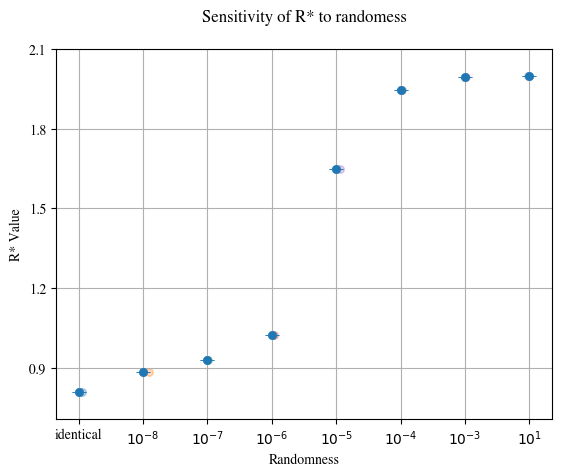

"\ntable = pd.DataFrame({\n    'labels': labels,\n    'Mean': means,\n    'Min': mins,\n    'Max': maxs,\n    'Lower Error': lower_err,\n    'Upper Error': upper_err\n})\n\nprint(table.to_string(index=False))\n"

: 

In [ ]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2+ list3 +list4 +list5 +list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


#labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
labels = ['identical',r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{1}$']

datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

#plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])


ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 1.0
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list_id)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()


'''
table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))
'''

# Adding random noise to Asimov B22 J11 

In [2]:
#this code is for all_fixed_AdT2K: the 2 files are identical
# NEXT STEP: add more folders that have increasing levels of randomness, use notebook to infer 
path_to_identical= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_identical/")
path_to_1= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-8/")
path_to_2= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-7/")
path_to_3= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-6/")
path_to_4= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-5/")
path_to_5= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-4/")
path_to_6= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-3/")
path_to_7= Path("../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e+1/")

identical=[f"{path_to_identical}/{x}" for x in os.listdir(path_to_identical)] 
level1=[f'{path_to_1}/{y}' for y in os.listdir(path_to_1)]
level2=[f'{path_to_2}/{z}' for z in os.listdir(path_to_2)]
level3=[f'{path_to_3}/{a}' for a in os.listdir(path_to_3)]# these will be used later as args in functions (used to calc the dims of the data)
level4=[f'{path_to_4}/{b}' for b in os.listdir(path_to_4)]
level5=[f'{path_to_5}/{c}' for c in os.listdir(path_to_5)]
level6=[f'{path_to_6}/{b}' for b in os.listdir(path_to_6)]
level7=[f'{path_to_7}/{c}' for c in os.listdir(path_to_7)]




fitting_label = "ID"
paths = [identical, level1, level2, level3, level4,level5, level6, level7]
for i in paths:
    print(i)
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

temp_identical=[]
temp1=[]
temp2=[]
temp3=[]
temp4=[]
temp5=[]
temp6=[]
temp7=[]



for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        #chain_handler.ignore_plots(["xsec_20", "xsec_19",'baseline', 'density', 'Ye', 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        chain_handler.ignore_plots(["LogL_systematic_xsec_cov", "LogL"])
        chain_handler.add_additional_plots(["xsec_", 'sin2th_12', 'sin2th_23', 'sin2th_13', 'delm2_12', 'delm2_23', 'delta_cp'])
        # chain_handler.add_additional_plots("LogL", exact=True)
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["step>10000"])
        chain_handler.add_new_cuts(["LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()

        if lm == identical:
            temp_identical.append(chain_handler)
        elif lm == level1:
            temp1.append(chain_handler)
        elif lm == level2:
            temp2.append(chain_handler)
        elif lm == level3:
            temp3.append(chain_handler)
        elif lm == level4:
            temp4.append(chain_handler)
        elif lm == level5:
            temp5.append(chain_handler)
        elif lm == level6:
            temp6.append(chain_handler)
        elif lm == level7:
            temp7.append(chain_handler)


identical_data = temp_identical[0]
identical_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

level1_data = temp1[0]
level1_data.ttree_array['ID']= 0

level2_data = temp2[0]
level2_data.ttree_array['ID']= 0

level3_data = temp3[0]
level3_data.ttree_array['ID']= 0

level4_data= temp4[0]
level4_data.ttree_array['ID']=0

level5_data= temp5[0]
level5_data.ttree_array['ID']=0

level6_data= temp6[0]
level6_data.ttree_array['ID']=0

level7_data= temp7[0]
level7_data.ttree_array['ID']=0

# double check if the uniform dist is applied by identifying row (chian id =1) and coloumn (i.e xsec_0)

for id, chain in enumerate(temp_identical[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
identical_data.ttree_array = pd.concat([identical_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp1[1:], start = 1): 
    
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-8)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-8)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-8)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-8)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-8)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-8)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-8)
    level1_data.ttree_array = pd.concat([level1_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp2[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-7)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-7)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-7)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-7)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-7)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-7)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-7)

    level2_data.ttree_array = pd.concat([level2_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp3[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-6)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-6)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-6)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-6)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-6)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-6)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-6)
    level3_data.ttree_array = pd.concat([level3_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp4[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):
        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-5)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-5)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-5)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-5)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-5)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-5)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-5) 
    level4_data.ttree_array = pd.concat([level4_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp5[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-4)
    
    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-4)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-4)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-4)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-4)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-4)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-4) 
    level5_data.ttree_array = pd.concat([level5_data.ttree_array, chain.ttree_array])

for id, chain in enumerate(temp6[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*1e-3)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*1e-3)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*1e-3)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*1e-3)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*1e-3)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*1e-3)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*1e-3) 
    level6_data.ttree_array = pd.concat([level6_data.ttree_array, chain.ttree_array])


for id, chain in enumerate(temp7[1:], start = 1): 
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    for m in range(175):

        chain.ttree_array[f'xsec_{m}']= chain.ttree_array[f'xsec_{m}'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'xsec_{m}']))*10)

    chain.ttree_array[f'sin2th_12']= chain.ttree_array[f'sin2th_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_12']))*10)
    chain.ttree_array[f'sin2th_23']=chain.ttree_array[f'sin2th_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_23']))*10)
    chain.ttree_array[f'sin2th_13']=chain.ttree_array[f'sin2th_13'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'sin2th_13']))*10)
    chain.ttree_array[f'delm2_12']=chain.ttree_array[f'delm2_12'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_12']))*10)
    chain.ttree_array[f'delm2_23']=chain.ttree_array[f'delm2_23'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delm2_23']))*10)
    chain.ttree_array[f'delta_cp']=chain.ttree_array[f'delta_cp'].add(np.random.uniform(-1,1,size=len(chain.ttree_array[f'delta_cp']))*10)  

    level7_data.ttree_array = pd.concat([level7_data.ttree_array, chain.ttree_array])



# First step we need to initialise the factory
path_to_identical.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_id = MLFactory(identical_data, fitting_label, f"{path_to_identical}.pdf")

#hook up paths to MLFactory
path_to_1.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level1 = MLFactory(level1_data, fitting_label, f"{path_to_1}.pdf")

path_to_2.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level2 = MLFactory(level2_data, fitting_label, f"{path_to_2}.pdf")

path_to_3.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level3 = MLFactory(level3_data, fitting_label, f"{path_to_3}.pdf")

path_to_4.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level4 = MLFactory(level4_data, fitting_label, f"{path_to_4}.pdf")

path_to_5.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level5 = MLFactory(level5_data, fitting_label, f"{path_to_5}.pdf")

path_to_6.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level6 = MLFactory(level6_data, fitting_label, f"{path_to_6}.pdf")

path_to_7.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_level7 = MLFactory(level7_data, fitting_label, f"{path_to_7}.pdf")

['../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_identical/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1 copy.root', '../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_identical/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
['../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-8/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1 copy.root', '../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-8/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
['../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-7/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1 copy.root', '../models/demo_files 2/asimov_random_noise/B22JOB11/asimov_e-7/trimmed_MaCh3-joint2021_asimovB22_uniformND280binning_woRC_v25Mar2022_Perlmutter_job1_1.root']
['../models/demo

In [3]:
ml_model_id = ml_factory_id.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0257, max_iter=10, verbose=1, max_leaf_nodes=550, 
                                                   l2_regularization= 0.962, max_features=1.0, early_stopping=True, n_iter_no_change= 10) #contains identical data
ml_model_1 = ml_factory_level1.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07020000000000001, max_iter=10, verbose=1, max_leaf_nodes=220, 
                                                   l2_regularization= 0.8250000000000001, max_features=0.5, early_stopping=True, n_iter_no_change= 10)#contains level1 data)
ml_model_2 = ml_factory_level2.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0868, max_iter=10, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.395, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)

ml_model_3 = ml_factory_level3.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.0152, max_iter=10, verbose=1, max_leaf_nodes=100, 
                                                   l2_regularization= 0.87, max_features= 0.5, early_stopping=True, n_iter_no_change= 10)
ml_model_4 = ml_factory_level4.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.09000000000000001, max_iter=10, verbose=1, max_leaf_nodes=690, 
                                                   l2_regularization= 0.08700000000000001, max_features=0.4, early_stopping=True, n_iter_no_change= 10)
ml_model_5 = ml_factory_level5.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.07940000000000001, max_iter=10, verbose=1, max_leaf_nodes=300, 
                                                   l2_regularization= 0.295, max_features= 0.9, early_stopping=True, n_iter_no_change= 10)
ml_model_6 = ml_factory_level6.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.08370000000000001, max_iter=10, verbose=1, max_leaf_nodes=80, 
                                                   l2_regularization= 0.303, max_features=0.7000000000000001, early_stopping=True, n_iter_no_change= 10)
ml_model_7 = ml_factory_level7.make_interface('SciKit', 'histboostclass', loss='log_loss', learning_rate= 0.033400000000000006, max_iter=10, verbose=1, max_leaf_nodes=630, 
                                                   l2_regularization= 0.004, max_features= 0.4, early_stopping=True, n_iter_no_change= 10)
list_id=[]
list1=[]
list2=[]
list3=[]
list4=[]
list5=[]
list6=[]
list7=[]


datapoints= 1
for i in range(datapoints):
    ml_model_id.set_training_test_set(0.3)
    ml_model_id.train_model()
    y=ml_model_id.getRStar_vals(identical, ml_model_id)
    list_id.append(y)

for i in range(datapoints):
    ml_model_1.set_training_test_set(0.3)
    ml_model_1.train_model()
    y=ml_model_1.getRStar_vals(level1, ml_model_1)
    list1.append(y)

for i in range(datapoints):
    ml_model_2.set_training_test_set(0.3)
    ml_model_2.train_model()
    y=ml_model_2.getRStar_vals(level2, ml_model_2)
    list2.append(y)


for i in range(datapoints):
    ml_model_3.set_training_test_set(0.3)
    ml_model_3.train_model()
    y=ml_model_3.getRStar_vals(level3, ml_model_3)
    list3.append(y)

for i in range(datapoints):
    ml_model_4.set_training_test_set(0.3)
    ml_model_4.train_model()
    y=ml_model_4.getRStar_vals(level4, ml_model_4)
    list4.append(y)

for i in range(datapoints):
    ml_model_5.set_training_test_set(0.3)
    ml_model_5.train_model()
    y=ml_model_5.getRStar_vals(level5, ml_model_5)
    list5.append(y)

for i in range(datapoints):
    ml_model_6.set_training_test_set(0.3)
    ml_model_6.train_model()
    y=ml_model_6.getRStar_vals(level6, ml_model_6)
    list6.append(y)

for i in range(datapoints):
    ml_model_7.set_training_test_set(0.3)
    ml_model_7.train_model()
    y=ml_model_7.getRStar_vals(identical, ml_model_7)
    list7.append(y)

Training Model
Binning 0.949 GB of training data: 4.687 s
Binning 0.105 GB of validation data: 0.185 s
Fitting gradient boosted rounds:
Fit 10 trees in 13.762 s, (5500 total leaves)
Time spent computing histograms: 4.456s
Time spent finding best splits:  1.334s
Time spent applying splits:      0.740s
Time spent predicting:           0.013s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 0.4036506995304412

R*: 0.8073013990608824

...

Training Model
Binning 0.949 GB of training data: 3.926 s
Binning 0.105 GB of validation data: 0.232 s
Fitting gradient boosted rounds:
Fit 10 trees in 7.612 s, (211 total leaves)
Time spent computing histograms: 0.585s
Time spent finding best splits:  0.060s
Time spent applying splits:      0.079s
Time spent predicting:           0.013s


Number of independent MCMCs: 2 detected.

R* incoming

predictive accuracy: 1.0

R*: 2.0

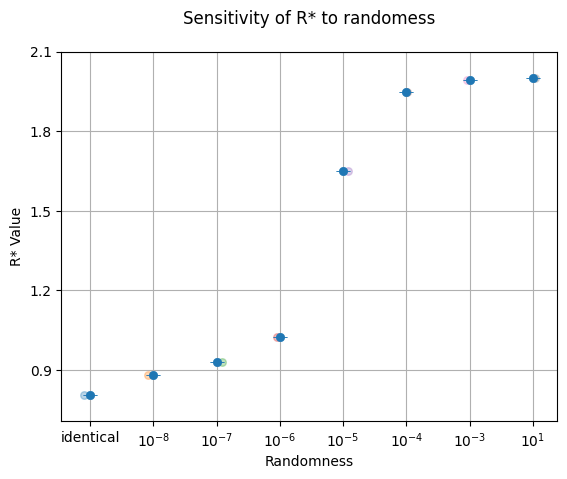

"\ntable = pd.DataFrame({\n    'labels': labels,\n    'Mean': means,\n    'Min': mins,\n    'Max': maxs,\n    'Lower Error': lower_err,\n    'Upper Error': upper_err\n})\n\nprint(table.to_string(index=False))\n"

In [4]:

lists=[list_id, list1, list2, list3, list4, list5, list6, list7]
concat= list_id + list1 + list2+ list3 +list4 +list5 +list6 +list7

means = np.array([np.mean(vals) for vals in lists])
mins  = np.array([np.min(vals)  for vals in lists])
maxs  = np.array([np.max(vals)  for vals in lists])

lower_err = means - mins
upper_err = maxs  - means
yerr = np.vstack((lower_err, upper_err))


x = np.arange(len(lists)) + 2   

plt.errorbar(x, means,
             yerr=yerr,
             fmt='o',        
             capsize=5,      
             elinewidth=0.5,
             markeredgewidth=0.5)


#labels = ['identical',r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$', r'$10^{1}$']
labels = ['identical',r'$10^{-8}$', r'$10^{-7}$', r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$', r'$10^{1}$']

datapoints = 2
def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

for xi, vals in zip(x, lists):
    jittered =    jittered_x = add_jitter([xi]*len(vals), scale=0.1)
    plt.scatter(jittered, vals, alpha=0.3, s=30)

#plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])
plt.xticks([2, 3, 4, 5, 6, 7, 8, 9], [labels[0], labels[1], labels[2], labels[3], labels[4], labels[5], labels[6], labels[7]])


ymin, ymax = min(concat), max(concat)
pad    = (ymax - ymin) * 1.0
plt.ylim(ymin - pad, ymax + pad)
plt.ylim(min(list_id)-0.1, max(list7)+0.1)

plt.gca().yaxis.set_major_locator(plt.MaxNLocator(5))   
plt.rcParams["font.family"] = "Times"
plt.title('Sensitivity of R* to randomess', pad=20)
plt.xlabel('Randomness')
plt.ylabel('R* Value')
plt.savefig('filename.png', dpi=900)
plt.grid(True)
plt.show()


'''
table = pd.DataFrame({
    'labels': labels,
    'Mean': means,
    'Min': mins,
    'Max': maxs,
    'Lower Error': lower_err,
    'Upper Error': upper_err
})

print(table.to_string(index=False))
'''